# Functional Capstone Project - Data & Analytics



## Business Context

**Infini Telco** is a prominent player in the telco industry with a strong presence in Malaysia. Specializing in B2B sales, they serve as a vital link in the supply chain, facilitating the distribution of telecommunication and technology products to retailers, service providers, and other businesses across the continent. 

Despite their market dominance and expansive product offerings, the company faces critical business challenge related to marketing strategy. A key aspect of this involves the ***identification and segmentation of their customer base into well-defined segments based on discernible patterns in product purchase behaviour and understand their product portfolio.*** By understanding the distinct needs, preferences, and purchasing habits of different customer segments, the client can develop targeted marketing strategies that cater to the specific needs of each segment, enhancing customer satisfaction and loyalty, driving revenue growth.




## Business Challenges

- No streamlined process to handle data and data is only available in chunks
- Limited intel on customer purchase patterns to drive targeted marketing
- Inadequate product insights across different customer groups


## Project Objectives

The business needs your help as a ***data analyst*** to overcome these challenges. Apply your data analytics skillset learnt.



### 1. Data Preprocessing

Data preparation is a critical process first step, involving the gathering, cleaning, transforming, and organizing of raw data into a format suitable for analysis. This step is essential for ensuring the quality and reliability of the insights derived from the data.

Here, the transaction data is provided from June 2020 to December 2022, which are stored across three separate csv files. The dataset are:

- Transactions_1.csv
- Transactions_2.csv
- Transactions_3.csv

***Task 1.1: Combine the transaction data files***

Find a way to combine the above data together into a singular dataframe, that will contain all the transactions at one place. Name this singular dataframe df_Txn_full.

In [90]:
#Import the necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import warnings
from sklearn.cluster import KMeans
from sklearn import preprocessing
from sklearn.metrics import silhouette_score
warnings.filterwarnings("ignore")

pd.options.display.float_format = '{:.2f}'.format
pd.options.display.max_rows = 100

In [91]:
import pandas as pd
print("Ready to analyze!")

Ready to analyze!


In [92]:
import pandas as pd

# Load the three transaction datasets
df_trans1 = pd.read_csv('Transactions_1.csv')
df_trans2 = pd.read_csv('Transactions_2.csv')
df_trans3 = pd.read_csv('Transactions_3.csv')

# Combine them vertically into one complete sales dataset
df_Txn_full = pd.concat([df_trans1, df_trans2, df_trans3], ignore_index=True)

# Let's check how many rows and columns we have in the combined data
print("Master dataset shape:", df_Txn_full.shape)
display(df_Txn_full.head())

Master dataset shape: (1353671, 12)


,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,GROSS_TURNOVER,AMOUNT
0,33806,124289578,10,2022-10-01,14816,14816,Customer Group_0,Responsible Employee_0,000000000000100095,ZSV,0.00,1
1,65627,124317609,230,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,000000000000100095,ZSV,0.00,1
2,65628,124317609,250,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,000000000000100095,ZSV,0.00,0
3,65629,124317609,270,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,000000000000100095,ZSV,0.00,1
4,65630,124317609,290,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,000000000000100095,ZSV,0.00,1


**Validation checkpoints:**
Consider, you would have received some information from the business on:

- Gross Annual Turnover for this period to be ~$1.4B
- The total unique products are ~190000
- The total customer base is ~7k

***Task 1.1.1***:

Use the above information to validate the data creation process. This is to ensure that no records of data are lost in the process. 

In [93]:
# 1. Validate Gross Annual Turnover (~$1.4B)
total_turnover = df_Txn_full['GROSS_TURNOVER'].sum()
print(f"Total Gross Turnover: ${total_turnover:,.2f}")

# 2. Validate Total Unique Products (~190k)
unique_products = df_Txn_full['PRODUCT'].nunique()
print(f"Total Unique Products: {unique_products}")

# 3. Validate Total Customer Base (~7k)
unique_customers = df_Txn_full['CUSTOMER_NUMBER'].nunique()
print(f"Total Unique Customers: {unique_customers}")

Total Gross Turnover: $1,466,478,196.72
Total Unique Products: 191394
Total Unique Customers: 7130


***Task 1.2: Join the mapping files to the transaction data***


Mapping files contain supplementary detailed information that will be used for our analysis. 
Use these mapping files to join with the above transaction data to create the master dataset <br><br>
**List of mapping files and their primary keys:**<br>
1. Customer Characteristics : to be joined on Customer Number
2. Customer Type Mapping : to be joined on Main Account ID
3. Product Category Mapping : to be joined on Product ID

To ensure that the joins are performed accurately, it is a good practice to clean up the columns upon which the join is performed. 
Some recommended steps to clean up a column are:

- ensuring the values are of the same data type
- removing leading zeroes
- removing leading and trailing whitespaces etc.


***Task 1.2.1:***

Here, before, performing the joins, you have to perform an intermediary step to clean up the below columns based on the above recommended steps:

- customer_number
- Product
- Main_account
- Invoice_Number

*Hint: Check for any leading or trailing 0s or white spaces.*

In [94]:
#Insert your code# List of columns to clean
cols_to_clean = ['CUSTOMER_NUMBER', 'PRODUCT', 'Main_account', 'INVOICE_NUMBER']

# Loop through each column and apply the cleaning steps
for col in cols_to_clean:
    # 1. Convert to string to ensure text manipulation works [cite: 158]
    df_Txn_full[col] = df_Txn_full[col].astype(str)
    
    # 2. Remove leading and trailing whitespaces [cite: 160]
    df_Txn_full[col] = df_Txn_full[col].str.strip()
    
    # 3. Remove leading zeros [cite: 159]
    df_Txn_full[col] = df_Txn_full[col].str.lstrip('0')

print("Columns cleaned successfully!")
# Display the cleaned columns to verify
display(df_Txn_full[cols_to_clean].head())

Columns cleaned successfully!


,CUSTOMER_NUMBER,PRODUCT,Main_account,INVOICE_NUMBER
0,14816,100095,14816,124289578
1,17566,100095,17566,124317609
2,17566,100095,17566,124317609
3,17566,100095,17566,124317609
4,17566,100095,17566,124317609


***Task 1.2.2:***

Import the mapping files and rename the dataframe:

- Customer Characteristics.csv : df_CustChar
- Customer Type Mapping.csv : df_CustType
- Product Categories.csv : df_ProdCategories

In [95]:
# Task 1.2.2: Import the mapping files
df_CustChar = pd.read_csv('Customer Characteristics.csv')
df_CustType = pd.read_csv('Customer Type Mapping.csv')
df_ProdCategories = pd.read_csv('Product Categories.csv', encoding='latin1')

# Let's display the first 2 rows of each to make sure they loaded correctly
print("Customer Characteristics:")
display(df_CustChar.head(2))

print("\nCustomer Type Mapping:")
display(df_CustType.head(2))

print("\nProduct Categories:")
display(df_ProdCategories.head(2))

Customer Characteristics:


,CUSTOMER_NAME,CUSTOMER_NUMBER,ACCOUNT_GROUP_TXT,CVR_Company_status
0,CUSTOMER_NAME_0,35016,Debtors,Normal
1,CUSTOMER_NAME_1,38336,Debtors,Normal



Customer Type Mapping:


,Main_account_ID,Customer_type
0,10014,A-B
1,10025,A-B



Product Categories:


,ProductID,ProductCategoryID,ProdCat2,ProdCat1
0,000000010001151351,739,Web Conferencing Services,Communication Tools
1,000000010000802665,739,Web Conferencing Services,Communication Tools


***Task 1.2.3:***

To perform join on the dataframes, it is important to clean the columns to ensure that the columns are free from any special characters.

- Remove any leading or trailing 0s in Customer_Number column in the df_CustChar dataframe.
- Check for duplicates in the data and remove any duplicates.
- Create a master dataframe by performing appropriate join on df_CustChar dataframe and df_Txn_full dataframe. Rename the master dataframe as df_Master.



In [96]:
# Task 1.2.3: Clean the key column in df_CustChar and join it to the master dataset

# 1. Clean the 'CUSTOMER_NUMBER' column in the mapping file
df_CustChar['CUSTOMER_NUMBER'] = df_CustChar['CUSTOMER_NUMBER'].astype(str)
df_CustChar['CUSTOMER_NUMBER'] = df_CustChar['CUSTOMER_NUMBER'].str.strip()
df_CustChar['CUSTOMER_NUMBER'] = df_CustChar['CUSTOMER_NUMBER'].str.lstrip('0')

# 2. Join the mapping file to the master dataset
# We use a 'left' join to keep all transaction records and just add the customer info where it matches
df_Master = pd.merge(df_Txn_full, df_CustChar, on='CUSTOMER_NUMBER', how='left')

# Let's check the shape and the new columns
print("New Master dataset shape:", df_Master.shape)
display(df_Master.head(2))

New Master dataset shape: (1353671, 15)


,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,GROSS_TURNOVER,AMOUNT,CUSTOMER_NAME,ACCOUNT_GROUP_TXT,CVR_Company_status
0,33806,124289578,10,2022-10-01,14816,14816,Customer Group_0,Responsible Employee_0,100095,ZSV,0.00,1,CUSTOMER_NAME_1429,Debtors,Normal
1,65627,124317609,230,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,0.00,1,CUSTOMER_NAME_573,Debtors,Normal


***Task 1.2.4:***

There is a data validation check point here. This is to ensure that you have not lost any data in the data preparation step.
Check and validate:

- Gross Annual Turnover is ~$1.4B
- The total customer base is ~7k

In [97]:
# Task 1.2.4: Validation Checkpoint
gross_annual_turnover_master = df_Master['GROSS_TURNOVER'].sum()
total_customer_base_master = df_Master['CUSTOMER_NUMBER'].nunique()

print(f"Gross Annual Turnover (df_Master): ${gross_annual_turnover_master:,.2f}")
print(f"Total Customer Base (df_Master): {total_customer_base_master}")

Gross Annual Turnover (df_Master): $1,466,478,196.72
Total Customer Base (df_Master): 7130


***Task 1.2.5:***

Now, you will be joining the df_CustType dataframe with the master dataframe.

- Remove any leading or trailing 0s in Main_account_ID column in the df_CustType dataframe.
- Check for duplicates in the data and remove any duplicates.
- Perform appropriate join on df_CustType dataframe and df_Master dataframe and save this merged dataframe as df_Master.

In [98]:
# Task 1.2.5: Clean df_CustType and join it to the master dataset
# 1. Clean the 'Main_account_ID' column in the mapping file
df_CustType['Main_account_ID'] = df_CustType['Main_account_ID'].astype(str)
df_CustType['Main_account_ID'] = df_CustType['Main_account_ID'].str.strip()
df_CustType['Main_account_ID'] = df_CustType['Main_account_ID'].str.lstrip('0')

# 2. Join the mapping file to the master dataset using a left join
# We use left_on and right_on because the column names are slightly different
df_Master = pd.merge(df_Master, df_CustType, left_on='Main_account', right_on='Main_account_ID', how='left')

# Let's check the shape and see the new 'Customer_type' column appended to the end
print("New Master dataset shape after adding Customer Type:", df_Master.shape)
display(df_Master.head(2))

New Master dataset shape after adding Customer Type: (1353671, 17)


,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,GROSS_TURNOVER,AMOUNT,CUSTOMER_NAME,ACCOUNT_GROUP_TXT,CVR_Company_status,Main_account_ID,Customer_type
0,33806,124289578,10,2022-10-01,14816,14816,Customer Group_0,Responsible Employee_0,100095,ZSV,0.00,1,CUSTOMER_NAME_1429,Debtors,Normal,14816,KAM
1,65627,124317609,230,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,0.00,1,CUSTOMER_NAME_573,Debtors,Normal,17566,A-B


***Task 1.2.6:***

There is a data validation check point here. This is to ensure that you have not lost any data in the data preparation step.
Check and validate:

- Gross Annual Turnover is ~$1.4B
- The total customer base is ~7k

In [99]:
gross_annual_turnover_master = df_Master['GROSS_TURNOVER'].sum()
total_customer_base_master = df_Master['CUSTOMER_NUMBER'].nunique()

print(f"Gross Annual Turnover (df_Master): ${gross_annual_turnover_master:,.2f}")
print(f"Total Customer Base (df_Master): {total_customer_base_master}")

Gross Annual Turnover (df_Master): $1,466,478,196.72
Total Customer Base (df_Master): 7130


***Task 1.2.7:***

Now, you will be joining the df_ProdCategories dataframe with the master dataframe.

- Remove any leading or trailing 0s in ProductID column in the df_ProdCategories dataframe.
- Check for duplicates in the data and remove any duplicates.
- Perform appropriate join on df_ProdCategories dataframe and df_Master dataframe and save this merged dataframe as df_Master.

In [100]:
# Clean 'ProductID' in df_ProdCategories
df_ProdCategories['ProductID'] = df_ProdCategories['ProductID'].astype(str).str.strip().str.lstrip('0')

# Check for and remove duplicates in df_ProdCategories
df_ProdCategories.drop_duplicates(inplace=True)

# Perform appropriate join on df_ProdCategories dataframe and df_Master dataframe
df_Master = pd.merge(df_Master, df_ProdCategories, left_on='PRODUCT', right_on='ProductID', how='left')

print(f"Shape of df_Master after joining df_ProdCategories: {df_Master.shape}")
display(df_Master.head())

Shape of df_Master after joining df_ProdCategories: (1353671, 21)


,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,...,AMOUNT,CUSTOMER_NAME,ACCOUNT_GROUP_TXT,CVR_Company_status,Main_account_ID,Customer_type,ProductID,ProductCategoryID,ProdCat2,ProdCat1
0,33806,124289578,10,2022-10-01,14816,14816,Customer Group_0,Responsible Employee_0,100095,ZSV,...,1,CUSTOMER_NAME_1429,Debtors,Normal,14816,KAM,100095,8.00,Music Streaming Services,Television and Entertainment
1,65627,124317609,230,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,1,CUSTOMER_NAME_573,Debtors,Normal,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment
2,65628,124317609,250,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,0,CUSTOMER_NAME_573,Debtors,Normal,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment
3,65629,124317609,270,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,1,CUSTOMER_NAME_573,Debtors,Normal,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment
4,65630,124317609,290,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,1,CUSTOMER_NAME_573,Debtors,Normal,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment


***Task 1.2.8:***

There is a data validation check point here. This is to ensure that you have not lost any data in the data preparation step.
Check and validate:

- Gross Annual Turnover is ~$1.4B
- The total customer base is ~7k
- The total product is ~15k

In [101]:
gross_annual_turnover_master = df_Master['GROSS_TURNOVER'].sum()
total_customer_base_master = df_Master['CUSTOMER_NUMBER'].nunique()
total_products_master = df_Master['PRODUCT'].nunique()

print(f"Gross Annual Turnover (df_Master): ${gross_annual_turnover_master:,.2f}")
print(f"Total Customer Base (df_Master): {total_customer_base_master}")
print(f"Total Products (df_Master): {total_products_master}")

Gross Annual Turnover (df_Master): $1,466,478,196.72
Total Customer Base (df_Master): 7130
Total Products (df_Master): 150545


***Task 1.3: Data Cleaning***

A major part of data pre processing involves cleaning the data, removing nulls, filtering out irrelavant or less useful information. For example:

- Remove rows with missing product id
- Removing rows with negative or zero turnover
- Removing customers who interacted very less 

As part of Data Cleaning of this dataset you are required to perform the following:

***Task 1.3.1: In the df_Master data, add a column Invoice_flag, reflecting 0 if number of transactions <= 3, otherwise 1***

This is to flag customers who purchase less frequently

In [102]:
# Calculate number of transactions per customer
transaction_counts = df_Master.groupby('CUSTOMER_NUMBER')['INVOICE_NUMBER'].nunique()

# Map the counts back to the df_Master
df_Master['Transaction_Count'] = df_Master['CUSTOMER_NUMBER'].map(transaction_counts)

# Add Invoice_flag: 0 if transaction count <= 3, otherwise 1
df_Master['Invoice_flag'] = df_Master['Transaction_Count'].apply(lambda x: 0 if x <= 3 else 1)

***Task 1.3.2: In the df_Master data, add a column Invoice_flag, reflecting 0 if number of transactions <= 3, otherwise 1***

This is to flag customers who purchase single SKU.

In [103]:
# Count unique SKUs using ProductID
sku_counts = df_Master.groupby('CUSTOMER_NUMBER')['ProductID'].nunique()

# Map back to df_Master
df_Master['SKU_Count'] = df_Master['CUSTOMER_NUMBER'].map(sku_counts)

# Flag customers who only bought 1 SKU
df_Master['SKU_flag'] = df_Master['SKU_Count'].apply(lambda x: 1 if x == 1 else 0)


There are a few records in the dataset whose Product ID are null. These records won't map to product information from the mapping file and hence these records will not be useful for the analysis.

***Task 1.3.3: In the master data, remove records where Product ID is null and save it in a dataframe df_Filtered***

In [104]:
df_Master[df_Master['ProductID'].isna()]

,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,...,Main_account_ID,Customer_type,ProductID,ProductCategoryID,ProdCat2,ProdCat1,Transaction_Count,Invoice_flag,SKU_Count,SKU_flag
2020,76372,801255849,10,2022-10-31,20184,20184,Customer Group_81,Responsible Employee_25,100278,ZKRE,...,20184,KAM,NaN,NaN,NaN,NaN,1182,1,643,0
2021,76373,801228459,10,2022-09-14,20184,20184,Customer Group_81,Responsible Employee_25,100278,ZKRE,...,20184,KAM,NaN,NaN,NaN,NaN,1182,1,643,0
2022,76374,801259417,10,2022-09-13,20184,20184,Customer Group_81,Responsible Employee_25,100278,ZKRE,...,20184,KAM,NaN,NaN,NaN,NaN,1182,1,643,0
2023,76375,801236727,10,2022-06-20,20184,20184,Customer Group_81,Responsible Employee_25,100278,ZKRE,...,20184,KAM,NaN,NaN,NaN,NaN,1182,1,643,0
2025,76377,801218208,10,2022-04-07,20184,20184,Customer Group_81,Responsible Employee_25,100278,ZKRE,...,20184,KAM,NaN,NaN,NaN,NaN,1182,1,643,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1335720,1167394,801289262,30,2022-12-01,401590,401590,Customer Group_403,Responsible Employee_41,100106,ZREQ,...,401590,KAM,NaN,NaN,NaN,NaN,1170,1,1543,0
1338063,1135872,123053929,100,2022-02-24,319700,319700,Customer Group_2440,Responsible Employee_2,100116,ZKOS,...,319700,A-B,NaN,NaN,NaN,NaN,637,1,1827,0
1338064,1135875,801219198,100,2022-02-24,319700,319700,Customer Group_2440,Responsible Employee_2,100116,ZKOS,...,319700,A-B,NaN,NaN,NaN,NaN,637,1,1827,0
1347665,1269105,801280725,20,2022-10-20,781120,781120,Customer Group_4526,Responsible Employee_66,100050,ZREQ,...,781120,C,NaN,NaN,NaN,NaN,30,1,73,0


In [105]:
# Remove records where Product ID is null
df_Filtered = df_Master.dropna(subset=['ProductID'])

print(f"Shape of df_Filtered after removing null ProductID: {df_Filtered.shape}")
display(df_Filtered.head())

Shape of df_Filtered after removing null ProductID: (1351546, 25)


,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,...,Main_account_ID,Customer_type,ProductID,ProductCategoryID,ProdCat2,ProdCat1,Transaction_Count,Invoice_flag,SKU_Count,SKU_flag
0,33806,124289578,10,2022-10-01,14816,14816,Customer Group_0,Responsible Employee_0,100095,ZSV,...,14816,KAM,100095,8.00,Music Streaming Services,Television and Entertainment,24,1,121,0
1,65627,124317609,230,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment,1502,1,2059,0
2,65628,124317609,250,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment,1502,1,2059,0
3,65629,124317609,270,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment,1502,1,2059,0
4,65630,124317609,290,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment,1502,1,2059,0


There are a few records that lack information on product category and will not be useful for the analysis

***Task 1.3.4: In the df_Filtered dataftame, remove records where Product Category information is null***


In [106]:
# Remove records where Product Category information is null (checking ProdCat1, ProdCat2, and ProductCategoryID)
df_Filtered = df_Filtered.dropna(subset=['ProdCat1', 'ProdCat2', 'ProductCategoryID'])

print(f"Shape of df_Filtered after removing null Product Category: {df_Filtered.shape}")
display(df_Filtered.head())

Shape of df_Filtered after removing null Product Category: (1351546, 25)


,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,...,Main_account_ID,Customer_type,ProductID,ProductCategoryID,ProdCat2,ProdCat1,Transaction_Count,Invoice_flag,SKU_Count,SKU_flag
0,33806,124289578,10,2022-10-01,14816,14816,Customer Group_0,Responsible Employee_0,100095,ZSV,...,14816,KAM,100095,8.00,Music Streaming Services,Television and Entertainment,24,1,121,0
1,65627,124317609,230,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment,1502,1,2059,0
2,65628,124317609,250,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment,1502,1,2059,0
3,65629,124317609,270,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment,1502,1,2059,0
4,65630,124317609,290,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment,1502,1,2059,0


In [107]:
df_Filtered[['ProdCat1', 'ProdCat2', 'ProductCategoryID']].isna().sum()


ProdCat1             0
ProdCat2             0
ProductCategoryID    0
dtype: int64

There are some sales made to Internal accounts in the dataset. These sales can be removed from analysis as information on internal sales can distort the analysis of customer behaviour. Internal transactions do not reflect the actual market demand or customer preferences.

***Task 1.3.5: In the df_Filtered dataframe, remove records pertaining to sales to Internal Account***

*Hint: Check for Internal accounts in Account_Group_TXT field*

In [108]:
df_Filtered[df_Filtered['ACCOUNT_GROUP_TXT'].str.contains('internal', case=False, na=False)]


,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,...,Main_account_ID,Customer_type,ProductID,ProductCategoryID,ProdCat2,ProdCat1,Transaction_Count,Invoice_flag,SKU_Count,SKU_flag
642,2921,124872382,10,2022-12-16,10701,10701,Customer Group_32,Responsible Employee_10,4333956942,ZLAG,...,10701,NaN,4333956942,601.00,Mobile Plans (Prepaid),Mobile Services,5,1,11,0
643,2930,123696118,10,2022-06-15,10701,10701,Customer Group_32,Responsible Employee_10,4443161274,ZLAG,...,10701,NaN,4443161274,600.00,Wholesale Telecom Services,Network and Infrastructure,5,1,11,0
891,2922,124872382,20,2022-12-16,10701,10701,Customer Group_32,Responsible Employee_10,4322803675,ZLAG,...,10701,NaN,4322803675,601.00,Mobile Plans (Prepaid),Mobile Services,5,1,11,0
892,2931,123696118,20,2022-06-15,10701,10701,Customer Group_32,Responsible Employee_10,4443161427,ZLAG,...,10701,NaN,4443161427,600.00,Wholesale Telecom Services,Network and Infrastructure,5,1,11,0
1071,2923,124872382,30,2022-12-16,10701,10701,Customer Group_32,Responsible Employee_10,4322803676,ZLAG,...,10701,NaN,4322803676,601.00,Mobile Plans (Prepaid),Mobile Services,5,1,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016095,1036742,801230451,230,2022-04-12,108022,108022,Customer Group_4569,Responsible Employee_8,4371894408,ZSRP,...,108022,NaN,4371894408,880.00,Network Monitoring Services,Network and Infrastructure,22,1,62,0
1016096,1036743,801230451,220,2022-04-12,108022,108022,Customer Group_4569,Responsible Employee_8,4371894130,ZSRP,...,108022,NaN,4371894130,880.00,Network Monitoring Services,Network and Infrastructure,22,1,62,0
1016097,1036746,801230451,190,2022-04-12,108022,108022,Customer Group_4569,Responsible Employee_8,4371200154,ZSRP,...,108022,NaN,4371200154,880.00,Network Monitoring Services,Network and Infrastructure,22,1,62,0
1016098,1036747,801230451,180,2022-04-12,108022,108022,Customer Group_4569,Responsible Employee_8,4370896258,ZSRP,...,108022,NaN,4370896258,880.00,Network Monitoring Services,Network and Infrastructure,22,1,62,0


In [109]:
# Remove records pertaining to sales to Internal Account
df_Filtered = df_Filtered[df_Filtered['ACCOUNT_GROUP_TXT'].str.lower() != 'internal accounts']

print(f"Shape of df_Filtered after removing Internal Accounts: {df_Filtered.shape}")
display(df_Filtered.head())

Shape of df_Filtered after removing Internal Accounts: (1351157, 25)


,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,...,Main_account_ID,Customer_type,ProductID,ProductCategoryID,ProdCat2,ProdCat1,Transaction_Count,Invoice_flag,SKU_Count,SKU_flag
0,33806,124289578,10,2022-10-01,14816,14816,Customer Group_0,Responsible Employee_0,100095,ZSV,...,14816,KAM,100095,8.00,Music Streaming Services,Television and Entertainment,24,1,121,0
1,65627,124317609,230,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment,1502,1,2059,0
2,65628,124317609,250,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment,1502,1,2059,0
3,65629,124317609,270,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment,1502,1,2059,0
4,65630,124317609,290,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment,1502,1,2059,0


As per business requirement, sales made to "ZSKA" and "ZDIR" are requested to be removed.

***Task 1.3.6: In the df_Filtered dataframe, remove records with position types "ZSKA" and "ZDIR"***

*Hint: Check column Position_type_order_line*

In [110]:
# Count how many rows have Position_type_order_line as 'ZSKA' or 'ZDIR'
to_delete_count = df_Filtered[df_Filtered['Position_type_order_line'].isin(['ZSKA', 'ZDIR'])].shape[0]
print(f"Number of rows with Position_type 'ZSKA' or 'ZDIR' that will be removed: {to_delete_count}")

Number of rows with Position_type 'ZSKA' or 'ZDIR' that will be removed: 48627


In [111]:
df_Filtered = df_Filtered[df_Filtered['Position_type_order_line'].isin(['ZSKA', 'ZDIR']) == False]

print(f"Shape of df_Filtered after removing ZSKA and ZDIR position types: {df_Filtered.shape}")
display(df_Filtered.head())

Shape of df_Filtered after removing ZSKA and ZDIR position types: (1302530, 25)


,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,...,Main_account_ID,Customer_type,ProductID,ProductCategoryID,ProdCat2,ProdCat1,Transaction_Count,Invoice_flag,SKU_Count,SKU_flag
0,33806,124289578,10,2022-10-01,14816,14816,Customer Group_0,Responsible Employee_0,100095,ZSV,...,14816,KAM,100095,8.00,Music Streaming Services,Television and Entertainment,24,1,121,0
1,65627,124317609,230,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment,1502,1,2059,0
2,65628,124317609,250,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment,1502,1,2059,0
3,65629,124317609,270,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment,1502,1,2059,0
4,65630,124317609,290,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment,1502,1,2059,0


Some companies are currently not active or are in normal operation. It makes sense to exclude these companies from analysis. But, for companies whose status is unknown (null/na), we still retain them.

***Task 1.3.7: In the df_Filtered dataframe, remove records whose company status are not active/normal***

*Hint: Check column CVR_Company_status*

In [112]:
# Count number of rows with Inactive status
inactive_count = df_Filtered[df_Filtered['CVR_Company_status'] == 'Inactive'].shape[0]
print(f"Number of rows with 'Inactive' status that would be removed: {inactive_count}")


Number of rows with 'Inactive' status that would be removed: 2556


In [113]:
# Keep only Active, Normal, and NULL statuses
df_Filtered = df_Filtered[
    df_Filtered['CVR_Company_status'].isin(['Active', 'Normal']) | df_Filtered['CVR_Company_status'].isna()
]

# Check the shape and first few rows
print(f"Shape of df_Filtered after keeping Active, Normal, and NULL: {df_Filtered.shape}")
display(df_Filtered.head())


Shape of df_Filtered after keeping Active, Normal, and NULL: (1299974, 25)


,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,...,Main_account_ID,Customer_type,ProductID,ProductCategoryID,ProdCat2,ProdCat1,Transaction_Count,Invoice_flag,SKU_Count,SKU_flag
0,33806,124289578,10,2022-10-01,14816,14816,Customer Group_0,Responsible Employee_0,100095,ZSV,...,14816,KAM,100095,8.00,Music Streaming Services,Television and Entertainment,24,1,121,0
1,65627,124317609,230,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment,1502,1,2059,0
2,65628,124317609,250,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment,1502,1,2059,0
3,65629,124317609,270,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment,1502,1,2059,0
4,65630,124317609,290,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment,1502,1,2059,0


There might be some records where Gross Turnover is zero or negative. These records might indicate product returns/invalid entries and should be excluded from the analysis.

***Task 1.3.8: In the df_Filtered dataframe, remove records where Gross Turnover is zero or negative***

In [114]:
# Count rows where GROSS_TURNOVER is zero or negative
zero_negative_count = df_Filtered[df_Filtered['GROSS_TURNOVER'] <= 0].shape[0]
print(f"Number of rows with zero or negative GROSS_TURNOVER: {zero_negative_count}")


Number of rows with zero or negative GROSS_TURNOVER: 29352


In [115]:
# Remove records where GROSS_TURNOVER is zero or negative
df_Filtered = df_Filtered[df_Filtered['GROSS_TURNOVER'] > 0]

print(f"Shape of df_Filtered after removing zero/negative GROSS_TURNOVER: {df_Filtered.shape}")
display(df_Filtered.head())


Shape of df_Filtered after removing zero/negative GROSS_TURNOVER: (1270622, 25)


,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,...,Main_account_ID,Customer_type,ProductID,ProductCategoryID,ProdCat2,ProdCat1,Transaction_Count,Invoice_flag,SKU_Count,SKU_flag
530,47154,124195645,10,2022-09-09,15082,103350,Customer Group_24,Responsible Employee_17,5737657492,ZLAG,...,103350,A-B,5737657492,605.00,Cloud Strategy and Migration,Digital Transformation Services,1575,1,2009,0
531,47184,124167744,70,2022-09-07,15082,103350,Customer Group_24,Responsible Employee_17,4441429746,ZLAG,...,103350,A-B,4441429746,686.00,Predictive Analytics,Data and Analytics,1575,1,2009,0
532,47455,123658470,100,2022-06-13,15082,103350,Customer Group_24,Responsible Employee_17,4289348828,ZLAG,...,103350,A-B,4289348828,660.00,Video Conferencing Services,Communication Tools,1575,1,2009,0
533,47585,123578961,530,2022-05-23,15082,103350,Customer Group_24,Responsible Employee_17,4325804446,ZLAG,...,103350,A-B,4325804446,601.00,Mobile Plans (Prepaid),Mobile Services,1575,1,2009,0
534,48190,123820272,10,2022-07-05,15082,103350,Customer Group_24,Responsible Employee_17,271354105,ZLAG,...,103350,A-B,271354105,756.00,Mobile TV Services,Television and Entertainment,1575,1,2009,0


There might be some records where Amount is zero or negative. These records might indicate product returns/invalid entries and should be excluded from the analysis.

***Task 1.3.9: In the df_Filtered dataframe, remove records where Amount is zero or negative***


In [116]:
# Count rows where AMOUNT is zero or negative
zero_negative_amount = df_Filtered[df_Filtered['AMOUNT'] <= 0].shape[0]
print(f"Number of rows with zero or negative AMOUNT: {zero_negative_amount}")


Number of rows with zero or negative AMOUNT: 189506


In [117]:
# Remove records where AMOUNT is zero or negative
df_Filtered = df_Filtered[df_Filtered['AMOUNT'] > 0]

print(f"Shape of df_Filtered after removing zero/negative AMOUNT: {df_Filtered.shape}")
display(df_Filtered.head())


Shape of df_Filtered after removing zero/negative AMOUNT: (1081116, 25)


,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,...,Main_account_ID,Customer_type,ProductID,ProductCategoryID,ProdCat2,ProdCat1,Transaction_Count,Invoice_flag,SKU_Count,SKU_flag
530,47154,124195645,10,2022-09-09,15082,103350,Customer Group_24,Responsible Employee_17,5737657492,ZLAG,...,103350,A-B,5737657492,605.00,Cloud Strategy and Migration,Digital Transformation Services,1575,1,2009,0
531,47184,124167744,70,2022-09-07,15082,103350,Customer Group_24,Responsible Employee_17,4441429746,ZLAG,...,103350,A-B,4441429746,686.00,Predictive Analytics,Data and Analytics,1575,1,2009,0
532,47455,123658470,100,2022-06-13,15082,103350,Customer Group_24,Responsible Employee_17,4289348828,ZLAG,...,103350,A-B,4289348828,660.00,Video Conferencing Services,Communication Tools,1575,1,2009,0
536,48255,124385024,480,2022-10-10,15082,103350,Customer Group_24,Responsible Employee_17,31592006,ZLAG,...,103350,A-B,31592006,756.00,Mobile TV Services,Television and Entertainment,1575,1,2009,0
538,48315,123063686,10,2022-03-02,15082,103350,Customer Group_24,Responsible Employee_17,JSF 505,ZLAG,...,103350,A-B,JSF 505,809.00,4G Services,Broadband and Internet Services,1575,1,2009,0


Remember, you had created a column to flag the customers whose number of transactions are 3 or less than that. Customers with very few transactions may introduce noise into the data, making it harder to identify meaningful patterns and trends. Filtering out these customers results in a cleaner dataset, which enhances the accuracy and reliability of the analysis.

***Task 1.3.10: In the df_Filtered dataframe, filter out customers who have made 3 or fewer transactions***

*Hint: Utilize the Invoice_flag column created earlier.*

In [118]:
# Count customers with 3 or fewer transactions
few_transactions_count = df_Filtered[df_Filtered['Invoice_flag'] == 0].shape[0]
print(f"Number of rows/customers with 3 or fewer transactions that will be removed: {few_transactions_count}")


Number of rows/customers with 3 or fewer transactions that will be removed: 5242


In [119]:
# Keep only customers with more than 3 transactions
df_Filtered = df_Filtered[df_Filtered['Invoice_flag'] == 1]

print(f"Shape of df_Filtered after removing customers with 3 or fewer transactions: {df_Filtered.shape}")
display(df_Filtered.head())


Shape of df_Filtered after removing customers with 3 or fewer transactions: (1075874, 25)


,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,...,Main_account_ID,Customer_type,ProductID,ProductCategoryID,ProdCat2,ProdCat1,Transaction_Count,Invoice_flag,SKU_Count,SKU_flag
530,47154,124195645,10,2022-09-09,15082,103350,Customer Group_24,Responsible Employee_17,5737657492,ZLAG,...,103350,A-B,5737657492,605.00,Cloud Strategy and Migration,Digital Transformation Services,1575,1,2009,0
531,47184,124167744,70,2022-09-07,15082,103350,Customer Group_24,Responsible Employee_17,4441429746,ZLAG,...,103350,A-B,4441429746,686.00,Predictive Analytics,Data and Analytics,1575,1,2009,0
532,47455,123658470,100,2022-06-13,15082,103350,Customer Group_24,Responsible Employee_17,4289348828,ZLAG,...,103350,A-B,4289348828,660.00,Video Conferencing Services,Communication Tools,1575,1,2009,0
536,48255,124385024,480,2022-10-10,15082,103350,Customer Group_24,Responsible Employee_17,31592006,ZLAG,...,103350,A-B,31592006,756.00,Mobile TV Services,Television and Entertainment,1575,1,2009,0
538,48315,123063686,10,2022-03-02,15082,103350,Customer Group_24,Responsible Employee_17,JSF 505,ZLAG,...,103350,A-B,JSF 505,809.00,4G Services,Broadband and Internet Services,1575,1,2009,0


You had also created a column to flag the customers who purchased only one sku. Such records in the data also tends to add noise and is necesary to filter these customers out.

***Task 1.3.11: In the df_Filtered dataframe, filter out customers who have purchased only a single SKU***

*Hint: Utilize the SKU_flag column created earlier.*

In [120]:
# Count rows where customers purchased only 1 SKU
single_sku_count = df_Filtered[df_Filtered['SKU_flag'] == 1].shape[0]
print(f"Number of rows/customers who purchased only 1 SKU (to be removed): {single_sku_count}")

Number of rows/customers who purchased only 1 SKU (to be removed): 210


In [121]:
# Keep only customers who purchased more than 1 SKU
df_Filtered = df_Filtered[df_Filtered['SKU_flag'] == 0]

print(f"Shape of df_Filtered after removing customers with only 1 SKU: {df_Filtered.shape}")
display(df_Filtered.head())

Shape of df_Filtered after removing customers with only 1 SKU: (1075664, 25)


,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,...,Main_account_ID,Customer_type,ProductID,ProductCategoryID,ProdCat2,ProdCat1,Transaction_Count,Invoice_flag,SKU_Count,SKU_flag
530,47154,124195645,10,2022-09-09,15082,103350,Customer Group_24,Responsible Employee_17,5737657492,ZLAG,...,103350,A-B,5737657492,605.00,Cloud Strategy and Migration,Digital Transformation Services,1575,1,2009,0
531,47184,124167744,70,2022-09-07,15082,103350,Customer Group_24,Responsible Employee_17,4441429746,ZLAG,...,103350,A-B,4441429746,686.00,Predictive Analytics,Data and Analytics,1575,1,2009,0
532,47455,123658470,100,2022-06-13,15082,103350,Customer Group_24,Responsible Employee_17,4289348828,ZLAG,...,103350,A-B,4289348828,660.00,Video Conferencing Services,Communication Tools,1575,1,2009,0
536,48255,124385024,480,2022-10-10,15082,103350,Customer Group_24,Responsible Employee_17,31592006,ZLAG,...,103350,A-B,31592006,756.00,Mobile TV Services,Television and Entertainment,1575,1,2009,0
538,48315,123063686,10,2022-03-02,15082,103350,Customer Group_24,Responsible Employee_17,JSF 505,ZLAG,...,103350,A-B,JSF 505,809.00,4G Services,Broadband and Internet Services,1575,1,2009,0


There are some information from the business and the business aligned on the fact that some very large customers are outliers and having them in the data could skew the analysis results. Hence, they should be filtered out. These customer types are denoted by KAM (Key Account Management).

***Task 1.3.12: In the df_Filtered dataframe, Filter out "Key" customer accounts***

*Hint: Check Customer_type column*

In [122]:
# Count rows where Customer_type is 'KAM' (Key customer accounts)
key_customers_count = df_Filtered[df_Filtered['Customer_type'] == 'KAM'].shape[0]
print(f"Number of rows for 'Key' customer accounts (to be removed): {key_customers_count}")

Number of rows for 'Key' customer accounts (to be removed): 236575


In [123]:
# Keep only customers that are not Key accounts
df_Filtered = df_Filtered[df_Filtered['Customer_type'] != 'KAM']

print(f"Shape of df_Filtered after removing 'Key' customer accounts: {df_Filtered.shape}")
display(df_Filtered.head())

Shape of df_Filtered after removing 'Key' customer accounts: (839089, 25)


,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,...,Main_account_ID,Customer_type,ProductID,ProductCategoryID,ProdCat2,ProdCat1,Transaction_Count,Invoice_flag,SKU_Count,SKU_flag
530,47154,124195645,10,2022-09-09,15082,103350,Customer Group_24,Responsible Employee_17,5737657492,ZLAG,...,103350,A-B,5737657492,605.00,Cloud Strategy and Migration,Digital Transformation Services,1575,1,2009,0
531,47184,124167744,70,2022-09-07,15082,103350,Customer Group_24,Responsible Employee_17,4441429746,ZLAG,...,103350,A-B,4441429746,686.00,Predictive Analytics,Data and Analytics,1575,1,2009,0
532,47455,123658470,100,2022-06-13,15082,103350,Customer Group_24,Responsible Employee_17,4289348828,ZLAG,...,103350,A-B,4289348828,660.00,Video Conferencing Services,Communication Tools,1575,1,2009,0
536,48255,124385024,480,2022-10-10,15082,103350,Customer Group_24,Responsible Employee_17,31592006,ZLAG,...,103350,A-B,31592006,756.00,Mobile TV Services,Television and Entertainment,1575,1,2009,0
538,48315,123063686,10,2022-03-02,15082,103350,Customer Group_24,Responsible Employee_17,JSF 505,ZLAG,...,103350,A-B,JSF 505,809.00,4G Services,Broadband and Internet Services,1575,1,2009,0


**With the above steps of data preprocessing, you now get a cleaned data set which will be used for further analysis.**

### 2. Data Transformation


***Task 2.1: Based on what you have learnt previously, perform a series of standard EDA to gain a better understanding of the data***

In [124]:
# 1. Basic info about dataframe
print("DataFrame Info:")
df_Filtered.info()

# 2. Summary statistics for numerical columns
print("\nDescriptive Statistics (numerical columns):")
display(df_Filtered.describe())

# 3. Distribution of key categorical columns
categorical_cols = ['CVR_Company_status', 'Customer_type', 'ProdCat1', 'ProdCat2']

for col in categorical_cols:
    print(f"\nValue counts for {col}:")
    display(df_Filtered[col].value_counts(dropna=False).head(10))

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 839089 entries, 530 to 1353670
Data columns (total 25 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   INDEX                          839089 non-null  int64  
 1   INVOICE_NUMBER                 839089 non-null  object 
 2   INVOICE_ITEM                   839089 non-null  int64  
 3   DOCUMENT_DATE                  839089 non-null  object 
 4   CUSTOMER_NUMBER                839089 non-null  object 
 5   Main_account                   839089 non-null  object 
 6   Main_account_name              839089 non-null  object 
 7   Main_resposible_employee_name  839089 non-null  object 
 8   PRODUCT                        839089 non-null  object 
 9   Position_type_order_line       839089 non-null  object 
 10  GROSS_TURNOVER                 839089 non-null  float64
 11  AMOUNT                         839089 non-null  int64  
 12  CUSTOMER_NAME   

,INDEX,INVOICE_ITEM,GROSS_TURNOVER,AMOUNT,ProductCategoryID,Transaction_Count,Invoice_flag,SKU_Count,SKU_flag
count,839089.00,839089.00,839089.00,839089.00,839089.00,839089.00,839089.00,839089.00,839089.00
mean,701653.01,891.62,1109.98,94.85,565.43,726.88,1.00,1178.37,0.00
std,398857.97,2415.00,4426.99,799.16,241.75,914.06,0.00,1622.00,0.00
min,1.00,1.00,0.01,1.00,1.00,4.00,1.00,2.00,0.00
25%,315109.00,50.00,116.00,1.00,318.00,119.00,1.00,263.00,0.00
50%,730111.00,200.00,296.59,5.00,603.00,352.00,1.00,651.00,0.00
75%,1046709.00,850.00,823.40,23.00,756.00,968.00,1.00,1404.00,0.00
max,1353670.00,66600.00,552378.84,148800.00,999.00,4664.00,1.00,9402.00,0.00



Value counts for CVR_Company_status:


CVR_Company_status
Normal    727430
Active    101151
NaN        10508
Name: count, dtype: int64


Value counts for Customer_type:


Customer_type
A-B    695867
D       71034
C       67430
NaN      4758
Name: count, dtype: int64


Value counts for ProdCat1:


ProdCat1
Television and Entertainment       146074
Network and Infrastructure         141206
Mobile Services                    115222
Business Solutions                  75285
Cloud and Hosting Services          67513
Digital Transformation Services     52082
Security and Privacy                42947
Devices and Accessories             38223
Data and Analytics                  29325
Broadband and Internet Services     27160
Name: count, dtype: int64


Value counts for ProdCat2:


ProdCat2
Mobile Plans (Prepaid)             71409
Mobile TV Services                 36555
Managed IT Services                34201
Network Infrastructure Services    34054
Premium TV Channels                29629
Wholesale Telecom Services         23551
Mobile Device Management (MDM)     22395
Network Equipment Sales            20110
Cloud-native Development           18264
Network Maintenance Services       17235
Name: count, dtype: int64

## Pareto Analysis

**Pareto Analysis** is a strategic decision-making tool used to prioritize actions based on the principle that a small number of causes typically lead to a large portion of the effects. Known as the 80/20 rule or the Pareto Principle, this concept is highly applicable in customer and product management, helping businesses focus on the most impactful areas to maximize efficiency and profitability.

## Key Concepts


**i) Pareto Principle (80/20 Rule):**

In the context of customers and products, this principle suggests that roughly 80% of a company’s revenue comes from 20% of its customers or products. Understanding this can help businesses focus their efforts on the most valuable segments.

**ii) Pareto Chart:**

A Pareto chart is a graphical tool that helps visualize and prioritize the most significant factors among a set. It combines a bar graph and a line graph, where bars represent individual values in descending order, and the line shows the cumulative total.

***An example of Pareto Chart and Pareto Analysis:***

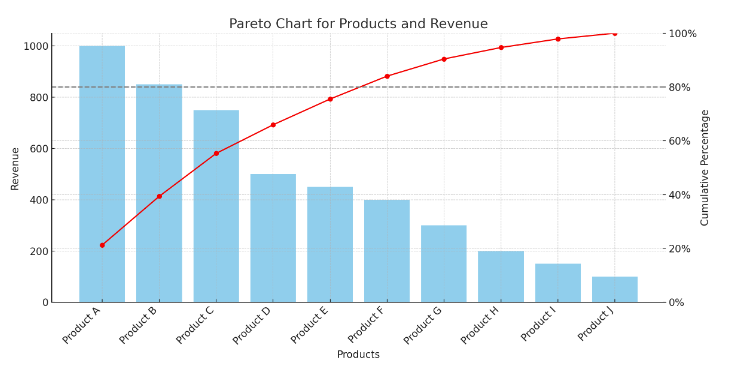

Here is the Pareto chart for products and their corresponding revenues. The chart consists of two key elements:

**Bar Chart:** The blue bars represent the individual revenue contributions of each product, sorted in descending order.

**Line Chart:** The red line shows the cumulative percentage of the total revenue contributed by the products. The horizontal 
gray dashed line indicates the 80% mark.

***Analysis***

- Product Contribution: The first few products (A, B, and C) generate a significant portion of the revenue, highlighting the "vital few" that follow the Pareto Principle.
- Cumulative Percentage: By the time we include Product E, the cumulative revenue reaches around 80% of the total, illustrating that a small number of products contribute to the majority of the revenue.

***Implications***

- Focus on Key Products: Efforts should be concentrated on optimizing and promoting these top-performing products to maximize revenue.
- Resource Allocation: Inventory, marketing, and development resources should be prioritized for these high-impact products to enhance business efficiency and profitability.
- Customer Strategies: Understanding which products are most valued by customers can help in tailoring marketing and customer engagement strategies.


Using Pareto analysis helps businesses identify and focus on the most impactful products, ensuring efficient use of resources and targeted efforts towards driving revenue growth. 

To execute the pareto analysis, you must create the required dataset. There are two levels of Product category in this dataset, use ProdCat2 for this analysis.

***Task 2.2: Create a new dataframe df_Pareto with the columns: ProdCat2, Gross_Turnover, Cumulative_GT, Cumulative_GT%***

*Hint: Cumulative_GT is Cumulative Gross Turnover which you can get by doing a cumulative sum on the Gross Turnover.*



In [125]:
# Aggregate Gross Turnover by ProdCat2
df_Pareto = df_Filtered.groupby('ProdCat2')['GROSS_TURNOVER'].sum().reset_index()
# Sort by Gross Turnover descending
df_Pareto = df_Pareto.sort_values(by='GROSS_TURNOVER', ascending=False).reset_index(drop=True)
# Cumulative Gross Turnover
df_Pareto['Cumulative_GT'] = df_Pareto['GROSS_TURNOVER'].cumsum()
# Total Gross Turnover
total_gross_turnover = df_Pareto['GROSS_TURNOVER'].sum()
# Cumulative GT %
df_Pareto['Cumulative_GT%'] = (df_Pareto['Cumulative_GT'] / total_gross_turnover) * 100

print(f"Shape of df_Pareto: {df_Pareto.shape}")
display(df_Pareto.head())

Shape of df_Pareto: (219, 4)


,ProdCat2,GROSS_TURNOVER,Cumulative_GT,Cumulative_GT%
0,Mobile Plans (Postpaid),56125893.61,56125893.61,6.03
1,Network Infrastructure Services,40887789.80,97013683.41,10.42
2,Broadband Internet (Fiber),40535399.72,137549083.13,14.77
3,Mobile Plans (Prepaid),31599641.39,169148724.52,18.16
4,Wholesale Telecom Services,25938239.22,195086963.74,20.95


***Task 2.3: Arrive at a "Pareto filtered" dataset df_Pareto_80 with the top product categories that contribute to 80% of the Gross Turnover***

*Hint: There are 64 products that contribute to 80% of Gross Revenue turnover*

In [126]:
# Create df_Pareto_80 with top 64 products
df_Pareto_80 = df_Pareto[df_Pareto['Cumulative_GT%'] <= 80].copy()

print(f"Shape of df_Pareto_80 (top 80% revenue products): {df_Pareto_80.shape}")
display(df_Pareto_80)

Shape of df_Pareto_80 (top 80% revenue products): (64, 4)


,ProdCat2,GROSS_TURNOVER,Cumulative_GT,Cumulative_GT%
0,Mobile Plans (Postpaid),56125893.61,56125893.61,6.03
1,Network Infrastructure Services,40887789.80,97013683.41,10.42
2,Broadband Internet (Fiber),40535399.72,137549083.13,14.77
3,Mobile Plans (Prepaid),31599641.39,169148724.52,18.16
4,Wholesale Telecom Services,25938239.22,195086963.74,20.95
5,Enterprise networking equipment,25240509.84,220327473.58,23.66
6,Cloud and Hosting Services,23595223.59,243922697.18,26.19
7,5G Services,22058524.35,265981221.53,28.56
8,4G Services,20518542.81,286499764.34,30.76
9,Carrier Services,20127006.33,306626770.67,32.92


***Task 2.3: Display the Pareto Chart***

*Hint: Your Pareto Chart will look something like this*

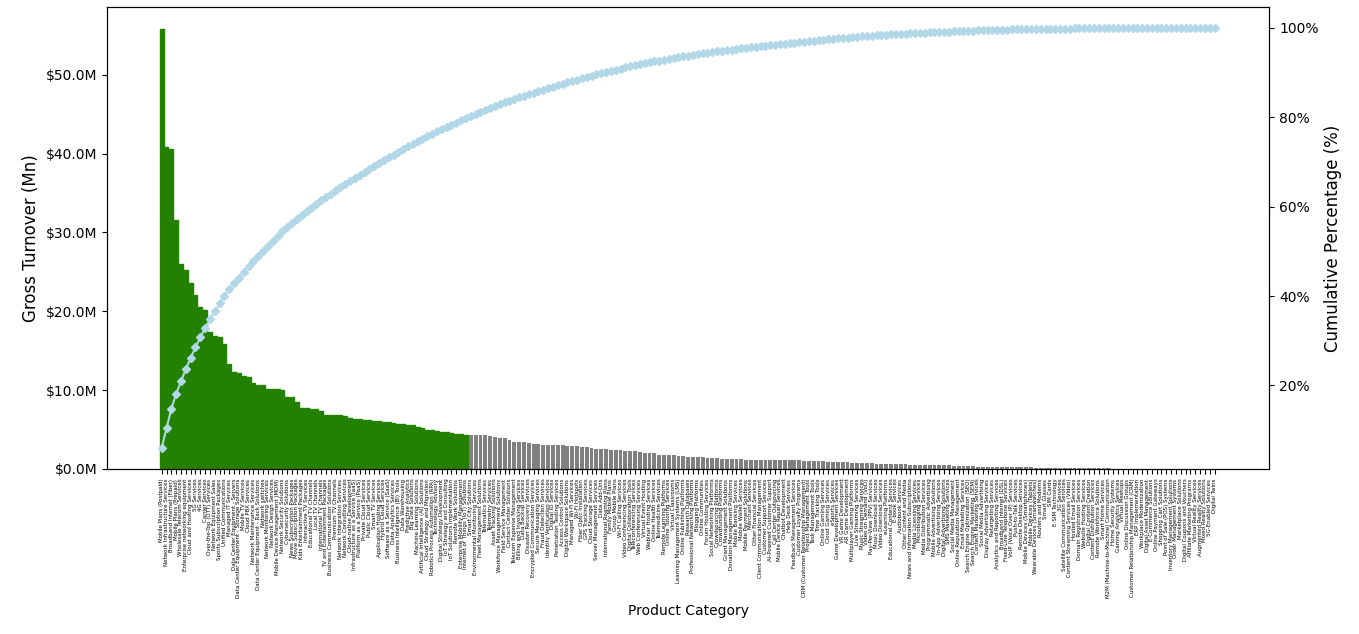


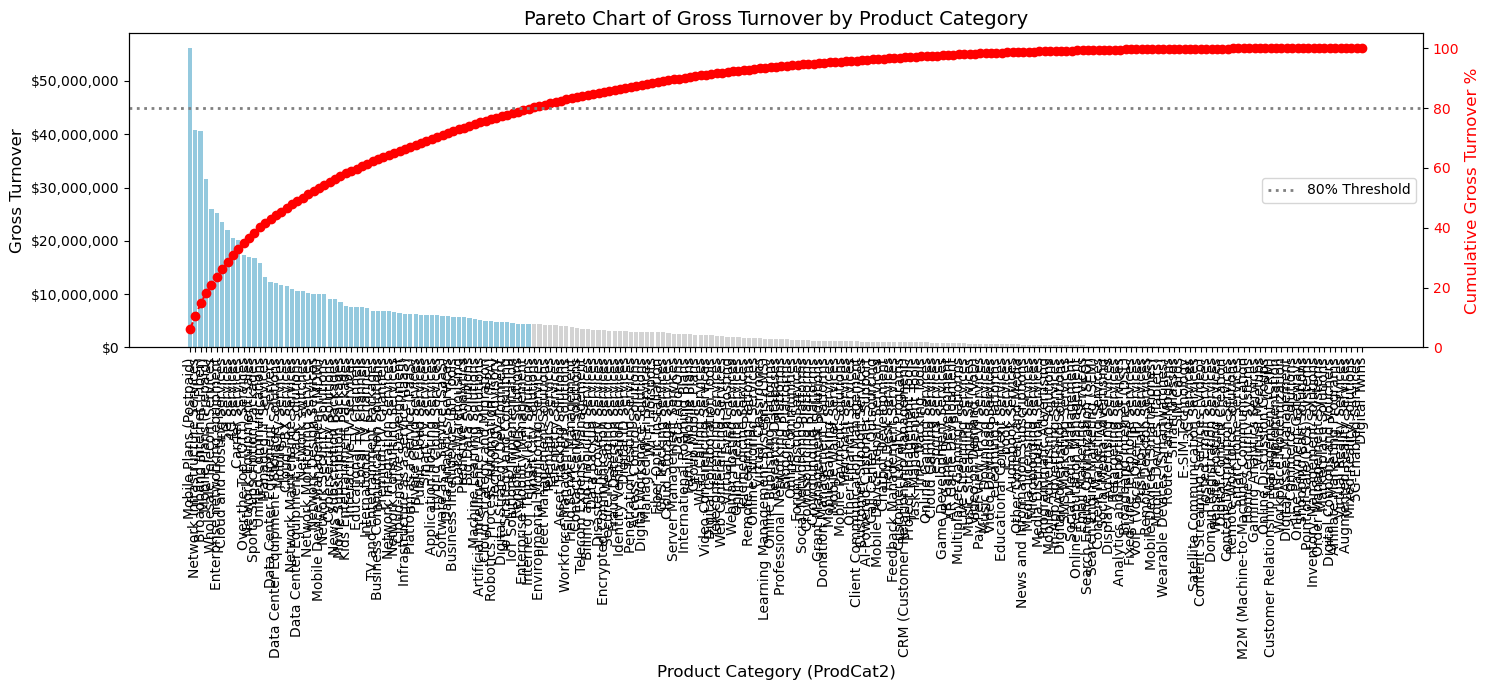

In [127]:
# Create a color list: blue for top 80%, gray for the rest
colors = ['skyblue' if x <= 80 else 'lightgray' for x in df_Pareto['Cumulative_GT%']]

fig, ax1 = plt.subplots(figsize=(15, 7))

# Bar chart with custom colors
sns.barplot(x='ProdCat2', y='GROSS_TURNOVER', data=df_Pareto, ax=ax1, palette=colors)
ax1.set_xlabel('Product Category (ProdCat2)', fontsize=12)
ax1.set_ylabel('Gross Turnover', fontsize=12)
ax1.set_title('Pareto Chart of Gross Turnover by Product Category', fontsize=14)
ax1.tick_params(axis='x', rotation=90)
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x:,.0f}')) # Format y-axis as currency

# Line chart for cumulative percentage
ax2 = ax1.twinx()
ax2.plot(df_Pareto['ProdCat2'], df_Pareto['Cumulative_GT%'], color='red', marker='o', linestyle='--')
ax2.set_ylabel('Cumulative Gross Turnover %', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 105)
ax2.axhline(80, color='gray', linestyle=':', linewidth=2, label='80% Threshold')
ax2.legend(loc='center right')

plt.tight_layout()
plt.show()



***Task 2.4: Perform the necessary action to map the top products from Pareto Analysis to the previously created master dataframe df_Filtered and store this in a new dataframe df_Filtered_Pareto.***

*Hint: Think Joins?*

In [128]:
# List of top products (from Pareto 80%)
top_products = df_Pareto_80['ProdCat2']

# Count rows that would be kept
rows_to_keep = df_Filtered['ProdCat2'].isin(top_products).sum()

# Count rows that would be removed
rows_to_remove = df_Filtered.shape[0] - rows_to_keep

print(f"Total rows in df_Filtered: {df_Filtered.shape[0]}")
print(f"Rows to keep (top products): {rows_to_keep}")
print(f"Rows that would be removed: {rows_to_remove}")


Total rows in df_Filtered: 839089
Rows to keep (top products): 644957
Rows that would be removed: 194132


In [130]:
# df_Pareto_80 contains top products contributing to 80% revenue
top_products = df_Pareto_80['ProdCat2']

# Filter df_Filtered to keep only rows with these top products
df_Filtered_Pareto = df_Filtered[df_Filtered['ProdCat2'].isin(top_products)].copy()

print(f"Shape of df_Filtered_Pareto (top products only): {df_Filtered_Pareto.shape}")
display(df_Filtered_Pareto.head())


Shape of df_Filtered_Pareto (top products only): (644957, 25)


,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,...,Main_account_ID,Customer_type,ProductID,ProductCategoryID,ProdCat2,ProdCat1,Transaction_Count,Invoice_flag,SKU_Count,SKU_flag
530,47154,124195645,10,2022-09-09,15082,103350,Customer Group_24,Responsible Employee_17,5737657492,ZLAG,...,103350,A-B,5737657492,605.00,Cloud Strategy and Migration,Digital Transformation Services,1575,1,2009,0
531,47184,124167744,70,2022-09-07,15082,103350,Customer Group_24,Responsible Employee_17,4441429746,ZLAG,...,103350,A-B,4441429746,686.00,Predictive Analytics,Data and Analytics,1575,1,2009,0
536,48255,124385024,480,2022-10-10,15082,103350,Customer Group_24,Responsible Employee_17,31592006,ZLAG,...,103350,A-B,31592006,756.00,Mobile TV Services,Television and Entertainment,1575,1,2009,0
538,48315,123063686,10,2022-03-02,15082,103350,Customer Group_24,Responsible Employee_17,JSF 505,ZLAG,...,103350,A-B,JSF 505,809.00,4G Services,Broadband and Internet Services,1575,1,2009,0
539,48316,123063686,30,2022-03-02,15082,103350,Customer Group_24,Responsible Employee_17,JSF 406,ZLAG,...,103350,A-B,JSF 406,809.00,4G Services,Broadband and Internet Services,1575,1,2009,0


In the above dataset, you will notice that there are some columns that are repititive and redundant.

***Task 2.5: Remove the redundant columns and give a meaningful name to the repititive columns***

In [131]:
# Print all columns in df_Filtered_Pareto
print("Columns in df_Filtered_Pareto:")
for i, col in enumerate(df_Filtered_Pareto.columns, start=1):
    print(f"{i}. {col}")

Columns in df_Filtered_Pareto:
1. INDEX
2. INVOICE_NUMBER
3. INVOICE_ITEM
4. DOCUMENT_DATE
5. CUSTOMER_NUMBER
6. Main_account
7. Main_account_name
8. Main_resposible_employee_name
9. PRODUCT
10. Position_type_order_line
11. GROSS_TURNOVER
12. AMOUNT
13. CUSTOMER_NAME
14. ACCOUNT_GROUP_TXT
15. CVR_Company_status
16. Main_account_ID
17. Customer_type
18. ProductID
19. ProductCategoryID
20. ProdCat2
21. ProdCat1
22. Transaction_Count
23. Invoice_flag
24. SKU_Count
25. SKU_flag


In [132]:
# Columns to drop redundant
columns_to_drop = [
   'INVOICE_ITEM', 'Main_resposible_employee_name', 'SKU_Count', 'SKU_flag', 'Transaction_Count'
]

# Drop columns
df_Cleaned = df_Filtered_Pareto.drop(columns=columns_to_drop, errors='ignore')

df_Cleaned = df_Cleaned.reset_index(drop=True)

print(f"Shape of df_Cleaned: {df_Cleaned.shape}")
display(df_Cleaned.head())


Shape of df_Cleaned: (644957, 20)


,INDEX,INVOICE_NUMBER,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,PRODUCT,Position_type_order_line,GROSS_TURNOVER,AMOUNT,CUSTOMER_NAME,ACCOUNT_GROUP_TXT,CVR_Company_status,Main_account_ID,Customer_type,ProductID,ProductCategoryID,ProdCat2,ProdCat1,Invoice_flag
0,47154,124195645,2022-09-09,15082,103350,Customer Group_24,5737657492,ZLAG,3870.22,1,CUSTOMER_NAME_2958,Debtors,Active,103350,A-B,5737657492,605.00,Cloud Strategy and Migration,Digital Transformation Services,1
1,47184,124167744,2022-09-07,15082,103350,Customer Group_24,4441429746,ZLAG,286.81,1,CUSTOMER_NAME_2958,Debtors,Active,103350,A-B,4441429746,686.00,Predictive Analytics,Data and Analytics,1
2,48255,124385024,2022-10-10,15082,103350,Customer Group_24,31592006,ZLAG,52.31,1,CUSTOMER_NAME_2958,Debtors,Active,103350,A-B,31592006,756.00,Mobile TV Services,Television and Entertainment,1
3,48315,123063686,2022-03-02,15082,103350,Customer Group_24,JSF 505,ZLAG,611.54,1,CUSTOMER_NAME_2958,Debtors,Active,103350,A-B,JSF 505,809.00,4G Services,Broadband and Internet Services,1
4,48316,123063686,2022-03-02,15082,103350,Customer Group_24,JSF 406,ZLAG,434.45,1,CUSTOMER_NAME_2958,Debtors,Active,103350,A-B,JSF 406,809.00,4G Services,Broadband and Internet Services,1


**This analysis gives an understanding of the top product portfolio of the company. This will be further used to perform customer segmentation.**

### 3. Customer Segmentation

The next part in this analysis is to find meaningful customer segments from the product purchase behaviour. 

You will use **KMeans Clustering Algorithm** for this.

### KMeans Algorithm 
The KMeans algorithm is a popular clustering technique used to partition a dataset into K clusters, where each data point belongs to the cluster with the nearest mean. Here are the steps involved in the KMeans algorithm:

**Initialization:**

- Choose the optimal number of clusters K, say 3 in this case. 
- Randomly select K data points from the dataset as the initial centroids (cluster centers).

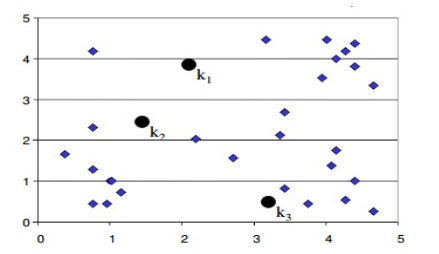

**Assignment Step:**

- Assign each data point to the nearest centroid. This is usually done by calculating the Euclidean distance between each data point and the centroids.
- Each data point is assigned to the cluster whose centroid is closest to it.

**Update Step:**

- Recalculate the centroids as the mean of all data points assigned to each cluster.
- The new centroid for each cluster is the average of the positions of all the data points in that cluster.

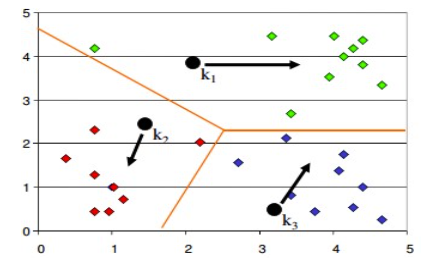

**Repeat:**

- Repeat the Assignment and Update steps until the centroids no longer change significantly or a specified number of iterations is reached.
- This convergence indicates that the clusters are stable, and the algorithm has found the optimal clustering.

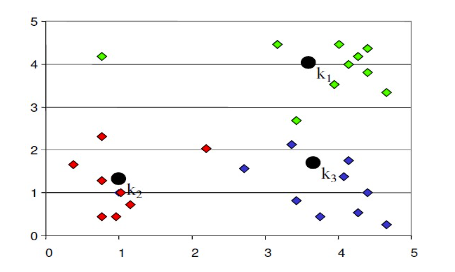

**Termination:**

- The algorithm terminates when the centroids have stabilized (i.e., they do not change significantly between iterations) or after a pre-defined number of iterations.



To execute this analysis, **Main Account** and **ProdCat1** (is a broader product category and is at the highest level in the product hierarchy) data will be used.

*Note: ProdCat2 level data is at a very granular level and performing clustering analysis on this might not give meaningful clusters.*

To proceed with the customer segmentation analysis, you need to menaingfully prepare the data.

***Task 3.1: Transform the data to feed to the clustering algorithm***

- Create a copy of the above dataframe and save it as **df_segment**
- Create a Primary Key: Concatenate the Main Account (ID) and Main Account Name
- Execute a groupby operation to calculate the annual turnover of each customer for each product (ProdCat1)
- Calculate the % spend by each customer across different product categories

The resultant dataframe will have the following columns:
- Primary Key
- ProdCat1
- Gross_Turnover
- Customer Spend %

In [133]:
print(f"Shape of df_Cleaned before Task 3.1: {df_Cleaned.shape}")

df_segment = df_Cleaned.copy()

# 2. Create Primary Key = ID + Name
df_segment['Primary_Key'] =  df_segment['Main_account'].astype(str)+ "_" +df_segment['Main_account_name']


# 3. Gross Turnover by customer × ProdCat1
df_turnover = ( df_segment.groupby(['Primary_Key', 'ProdCat1'])['GROSS_TURNOVER'].sum() .reset_index(name='Gross_Turnover'))

# 4. Total spend for each customer
df_total = (
    df_turnover.groupby('Primary_Key')['Gross_Turnover'].sum().reset_index(name='Total_Spend'))

# 5. Customer Spend % (multiply by 100 for proper percentage format)
df_turnover = df_turnover.merge(df_total, on='Primary_Key', how='left')
df_turnover['Customer_Spend_%'] = (
    (df_turnover['Gross_Turnover'] / df_turnover['Total_Spend']) * 100
)

# 6. Final output
df_result = df_turnover[['Primary_Key', 'ProdCat1', 'Gross_Turnover', 'Customer_Spend_%']]

# 7. Print shape after transformation
print(f"Shape of df_result after Task 3.1: {df_result.shape}")

# 8. Display first 5 rows
display(df_result.head())


Shape of df_Cleaned before Task 3.1: (644957, 20)
Shape of df_result after Task 3.1: (22692, 4)


,Primary_Key,ProdCat1,Gross_Turnover,Customer_Spend_%
0,100015_Customer Group_2149,Broadband and Internet Services,9250.04,44.25
1,100015_Customer Group_2149,Cloud and Hosting Services,124.69,0.60
2,100015_Customer Group_2149,Devices and Accessories,132.17,0.63
3,100015_Customer Group_2149,Digital Transformation Services,4106.33,19.65
4,100015_Customer Group_2149,Mobile Services,123.71,0.59


***Task 3.2: Pivot the dataset to create a matrix view of spend % of all customers on all products (ProdCat1). Save the dataframe as df_pivot. Create another dataframe df_clustering removing the primary key from the df_pivot dataframe.***

In [134]:

print(f"Shape of df_result before pivot: {df_result.shape}")

df_pivot = df_result.pivot(
    index='Primary_Key',
    columns='ProdCat1',
    values='Customer_Spend_%'
)

# Step 2: Fill missing values with 0 (if any)
df_pivot = df_pivot.fillna(0)

# Step 3: Save the pivoted DataFrame
print("Pivoted Dataset (df_pivot):")
display(df_pivot.head())

# Step 4: Create df_clustering by removing the Primary Key
# Since Primary_Key is the index in df_pivot, reset the index to remove it
df_clustering = df_pivot.reset_index(drop=True)

# Step 5: Display the clustering dataset
print("Clustering Dataset (df_clustering):")
display(df_clustering.head())

# Optional: check shapes
print(f"Shape of df_pivot: {df_pivot.shape}")
print(f"Shape of df_clustering: {df_clustering.shape}")



Shape of df_result before pivot: (22692, 4)
Pivoted Dataset (df_pivot):


ProdCat1,Broadband and Internet Services,Business Solutions,Cloud and Hosting Services,Data and Analytics,Devices and Accessories,Digital Transformation Services,IoT and Smart Solutions,Mobile Services,Network and Infrastructure,Security and Privacy,Television and Entertainment
Primary_Key,,,,,,,,,,,
100015_Customer Group_2149,44.25,0.00,0.60,0.00,0.63,19.65,0.00,0.59,23.84,0.00,10.44
100022_Customer Group_1631,0.00,18.88,6.79,0.00,12.55,0.00,0.00,5.43,10.35,44.61,1.39
100027_Customer Group_2392,34.30,0.00,1.03,1.42,0.00,0.00,0.00,35.76,4.64,0.00,22.84
100040_Customer Group_2150,0.00,5.05,4.29,0.00,0.00,0.00,0.00,0.66,89.41,0.00,0.59
100041_Customer Group_477,23.34,5.27,1.18,0.85,6.21,3.94,0.00,12.24,29.98,0.24,16.77


Clustering Dataset (df_clustering):


ProdCat1,Broadband and Internet Services,Business Solutions,Cloud and Hosting Services,Data and Analytics,Devices and Accessories,Digital Transformation Services,IoT and Smart Solutions,Mobile Services,Network and Infrastructure,Security and Privacy,Television and Entertainment
0,44.25,0.00,0.60,0.00,0.63,19.65,0.00,0.59,23.84,0.00,10.44
1,0.00,18.88,6.79,0.00,12.55,0.00,0.00,5.43,10.35,44.61,1.39
2,34.30,0.00,1.03,1.42,0.00,0.00,0.00,35.76,4.64,0.00,22.84
3,0.00,5.05,4.29,0.00,0.00,0.00,0.00,0.66,89.41,0.00,0.59
4,23.34,5.27,1.18,0.85,6.21,3.94,0.00,12.24,29.98,0.24,16.77


Shape of df_pivot: (3929, 11)
Shape of df_clustering: (3929, 11)


In [135]:
print("Total rows before filtering:", df_clustering.shape[0])

one_cat_count = (df_clustering.gt(0).sum(axis=1) == 1).sum()
print("Customers buying ONLY 1 category:", one_cat_count)

two_cat_count = (df_clustering.gt(0).sum(axis=1) == 2).sum()
print("Customers buying ONLY 2 categories:", two_cat_count)

cat_usage = df_clustering.gt(0).mean()
low_usage_cats = cat_usage[cat_usage < 0.05]
print("Categories purchased by <5% customers:")
print(low_usage_cats)

print("Category usage (% of customers using each):")
print((cat_usage * 100).round(2))



Total rows before filtering: 3929
Customers buying ONLY 1 category: 280
Customers buying ONLY 2 categories: 405
Categories purchased by <5% customers:
ProdCat1
IoT and Smart Solutions   0.02
dtype: float64
Category usage (% of customers using each):
ProdCat1
Broadband and Internet Services   32.99
Business Solutions                38.61
Cloud and Hosting Services        65.49
Data and Analytics                51.06
Devices and Accessories           50.78
Digital Transformation Services   59.68
IoT and Smart Solutions            2.39
Mobile Services                   70.17
Network and Infrastructure        75.18
Security and Privacy              52.23
Television and Entertainment      78.98
dtype: float64


### The Elbow Method in KMeans Clustering

The Elbow Method is a commonly used technique to determine the optimal number of clusters (K) in KMeans clustering. It helps to balance between underfitting and overfitting by finding a point where adding more clusters doesn’t significantly improve the model performance. 

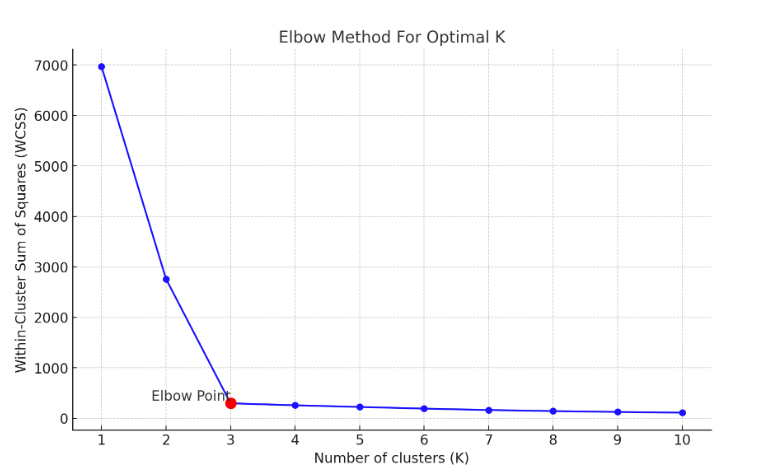

***Explanation of the Plot***

**WCSS (Within Cluster Sum of Squares) vs. Number of Clusters:**

- The x-axis represents the number of clusters (K).
- The y-axis represents the Within-Cluster Sum of Squares (WCSS), which measures the variance within each cluster.

**Plotting WCSS for Different K Values:**

- For each value of K (from 1 to 10), the KMeans algorithm is run, and the corresponding WCSS is calculated.
- The plot shows how WCSS decreases as the number of clusters increases.

**Elbow Point:**

- The red point marked on the plot indicates the "elbow point" where the rate of decrease in WCSS slows down.
- In this example, the elbow point is at K = 3. This suggests that 3 clusters are optimal for this dataset, as adding more clusters beyond this point results in only a marginal reduction in WCSS.

**Interpretation:**

- Before the Elbow Point: Adding more clusters significantly reduces WCSS, indicating that the clusters are becoming more defined and compact.
- After the Elbow Point: The reduction in WCSS slows down, meaning that adding more clusters doesn’t significantly improve the clustering.

**Conclusion** 

The Elbow Method helps to identify the optimal number of clusters by looking for the point where the WCSS starts to decrease at a slower rate, balancing model complexity and performance. In this case, the plot suggests that using 3 clusters is a good choice for the dataset.

***Task 3.3: Run K-Means clustering algorithm and identify the optimal number of clusters using Elbow Method***

In [136]:
data_array=df_clustering.iloc[:,[0,1,2,3,4,5,7,8,9,10]]
data_array

ProdCat1,Broadband and Internet Services,Business Solutions,Cloud and Hosting Services,Data and Analytics,Devices and Accessories,Digital Transformation Services,Mobile Services,Network and Infrastructure,Security and Privacy,Television and Entertainment
0,44.25,0.00,0.60,0.00,0.63,19.65,0.59,23.84,0.00,10.44
1,0.00,18.88,6.79,0.00,12.55,0.00,5.43,10.35,44.61,1.39
2,34.30,0.00,1.03,1.42,0.00,0.00,35.76,4.64,0.00,22.84
3,0.00,5.05,4.29,0.00,0.00,0.00,0.66,89.41,0.00,0.59
4,23.34,5.27,1.18,0.85,6.21,3.94,12.24,29.98,0.24,16.77
...,...,...,...,...,...,...,...,...,...,...
3924,0.00,0.00,0.00,0.00,0.00,0.00,100.00,0.00,0.00,0.00
3925,0.00,0.00,0.88,42.61,0.61,1.28,20.55,27.46,5.30,1.31
3926,7.40,0.00,7.64,17.97,3.05,25.35,3.75,21.43,2.85,10.56
3927,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,100.00


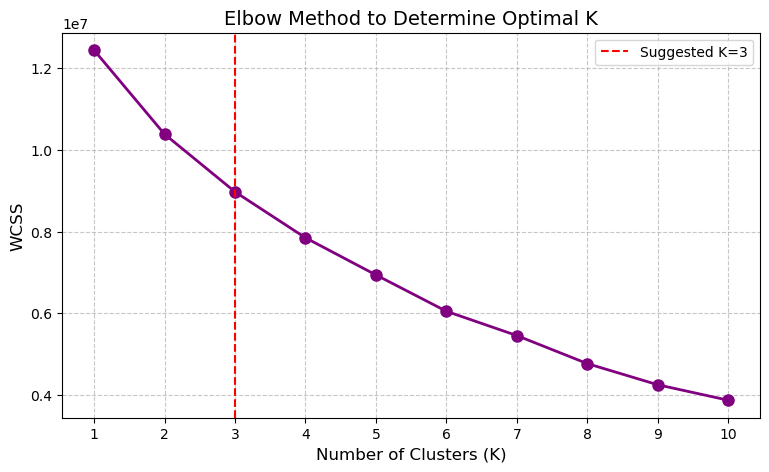

In [138]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
data_array = df_clustering.to_numpy()
wcss_list = []
k_values = range(1, 11)

for k in k_values:
    kmeans_model = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans_model.fit(data_array)
    wcss_list.append(kmeans_model.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(k_values, wcss_list, 'o-', color='purple', linewidth=2, markersize=8)
plt.title('Elbow Method to Determine Optimal K', fontsize=14)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('WCSS', fontsize=12)
plt.axvline(x=3, color='red', linestyle='--', label='Suggested K=3')
plt.xticks(k_values)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


The Elbow Curve provides an optimal value for 'k' that is the number of clusters to be generated in the output. This value can be used as a guideline for the actual clustering run; one may vary the number of clusers in the output based on business need.

***Task 3.4: Run the KMeans algorithm with optimal number of clusters***

In [139]:
optimal_k = 3
# Step 2: Initialize and fit the KMeans algorithm
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
kmeans.fit(df_clustering)

# Step 3: Add the cluster labels to the df_clustering DataFrame
df_clustering['Cluster'] = kmeans.labels_

# Step 4: Display the clustered dataset
print(f"Clustered DataFrame with {optimal_k} clusters:")
display(df_clustering.head())
print(df_clustering['Cluster'].value_counts())

Clustered DataFrame with 3 clusters:


ProdCat1,Broadband and Internet Services,Business Solutions,Cloud and Hosting Services,Data and Analytics,Devices and Accessories,Digital Transformation Services,IoT and Smart Solutions,Mobile Services,Network and Infrastructure,Security and Privacy,Television and Entertainment,Cluster
0,44.25,0.00,0.60,0.00,0.63,19.65,0.00,0.59,23.84,0.00,10.44,0
1,0.00,18.88,6.79,0.00,12.55,0.00,0.00,5.43,10.35,44.61,1.39,0
2,34.30,0.00,1.03,1.42,0.00,0.00,0.00,35.76,4.64,0.00,22.84,0
3,0.00,5.05,4.29,0.00,0.00,0.00,0.00,0.66,89.41,0.00,0.59,1
4,23.34,5.27,1.18,0.85,6.21,3.94,0.00,12.24,29.98,0.24,16.77,0


Cluster
0    2468
1     941
2     520
Name: count, dtype: int64


In [140]:
display(df_clustering.groupby('Cluster').mean())

ProdCat1,Broadband and Internet Services,Business Solutions,Cloud and Hosting Services,Data and Analytics,Devices and Accessories,Digital Transformation Services,IoT and Smart Solutions,Mobile Services,Network and Infrastructure,Security and Privacy,Television and Entertainment
Cluster,,,,,,,,,,,
0,8.36,5.38,13.05,5.80,8.86,10.81,0.94,16.95,11.17,8.77,9.92
1,1.32,1.84,5.51,3.55,3.56,4.57,0.14,6.79,60.98,2.70,9.06
2,2.71,2.87,4.03,2.22,3.21,4.31,0.11,5.76,8.69,2.02,64.06


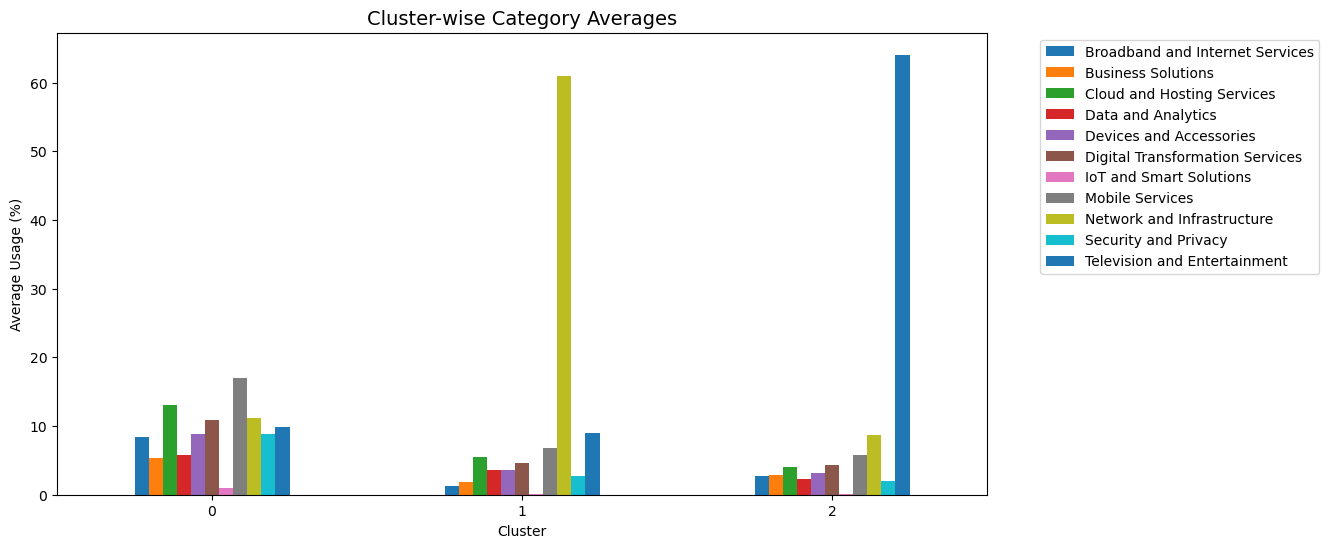

In [141]:
cluster_means = df_clustering.groupby('Cluster').mean()
cluster_means.plot(kind='bar', figsize=(12,6))
plt.title('Cluster-wise Category Averages', fontsize=14)
plt.xlabel('Cluster')
plt.ylabel('Average Usage (%)')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')  # move legend outside
plt.show()


***Task 3.5: From the above clusters, create cluster profile***

***Task 3.5.1: Map each customers to their respective cluster in df_segment dataset***

In [142]:
customer_clusters = pd.DataFrame({
    'Primary_Key': df_pivot.index,
    'Cluster': df_clustering['Cluster']
})

# Step 2: Merge cluster labels with the original df_segment dataset
df_segment_with_clusters = pd.merge(
    df_segment,
    customer_clusters[['Primary_Key', 'Cluster']],
    on='Primary_Key',
    how='left'
)

# Step 3: Verify the merged dataset
print("Segment Dataset with Clusters (df_segment_with_clusters):")
display(df_segment_with_clusters.head())

# Step 4: Optional - count number of customers per cluster
print("Number of customers per cluster:")
print(df_segment_with_clusters['Cluster'].value_counts())

Segment Dataset with Clusters (df_segment_with_clusters):


,INDEX,INVOICE_NUMBER,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,PRODUCT,Position_type_order_line,GROSS_TURNOVER,AMOUNT,...,CVR_Company_status,Main_account_ID,Customer_type,ProductID,ProductCategoryID,ProdCat2,ProdCat1,Invoice_flag,Primary_Key,Cluster
0,47154,124195645,2022-09-09,15082,103350,Customer Group_24,5737657492,ZLAG,3870.22,1,...,Active,103350,A-B,5737657492,605.00,Cloud Strategy and Migration,Digital Transformation Services,1,103350_Customer Group_24,0
1,47184,124167744,2022-09-07,15082,103350,Customer Group_24,4441429746,ZLAG,286.81,1,...,Active,103350,A-B,4441429746,686.00,Predictive Analytics,Data and Analytics,1,103350_Customer Group_24,0
2,48255,124385024,2022-10-10,15082,103350,Customer Group_24,31592006,ZLAG,52.31,1,...,Active,103350,A-B,31592006,756.00,Mobile TV Services,Television and Entertainment,1,103350_Customer Group_24,0
3,48315,123063686,2022-03-02,15082,103350,Customer Group_24,JSF 505,ZLAG,611.54,1,...,Active,103350,A-B,JSF 505,809.00,4G Services,Broadband and Internet Services,1,103350_Customer Group_24,0
4,48316,123063686,2022-03-02,15082,103350,Customer Group_24,JSF 406,ZLAG,434.45,1,...,Active,103350,A-B,JSF 406,809.00,4G Services,Broadband and Internet Services,1,103350_Customer Group_24,0


Number of customers per cluster:
Cluster
0    469797
1    127487
2     47673
Name: count, dtype: int64


***Task 3.5.2: Create a cluster profile table with the cluster label, Gross Turnover for each cluster, Number of unique customers in each cluster, % share of Gross Turnover of each cluster for each product.***

*Illustrative: Here is a snapshot of the desired cluster profile:*
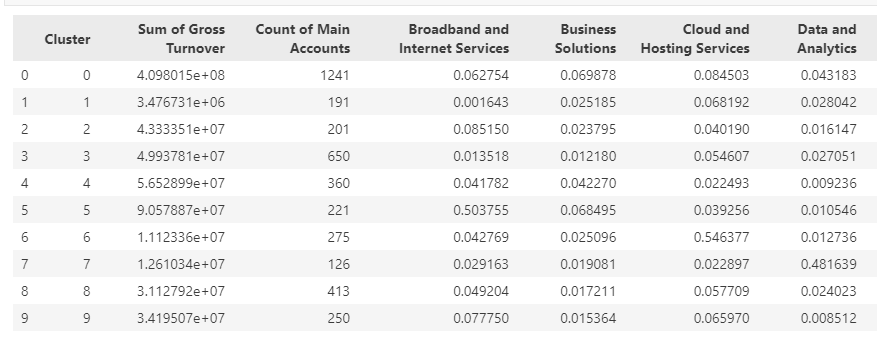

In [143]:
cluster_profile = df_segment_with_clusters.groupby('Cluster').agg(
    Total_Gross_Turnover=('GROSS_TURNOVER', 'sum'),
    Unique_Customers=('Primary_Key', 'nunique')
)

cluster_product_turnover = df_segment_with_clusters.groupby(
    ['Cluster', 'ProdCat1']
)['GROSS_TURNOVER'].sum().reset_index()

product_share = cluster_product_turnover.pivot_table(
    index='Cluster',
    columns='ProdCat1',
    values='GROSS_TURNOVER',
    aggfunc='sum'
)

product_share_pct = product_share.div(product_share.sum(axis=1), axis=0) * 100
cluster_profile = pd.concat([cluster_profile, product_share_pct], axis=1)
print("Cluster Profile Table (Correct % Share of Gross Turnover):")
display(cluster_profile)

Cluster Profile Table (Correct % Share of Gross Turnover):


,Total_Gross_Turnover,Unique_Customers,Broadband and Internet Services,Business Solutions,Cloud and Hosting Services,Data and Analytics,Devices and Accessories,Digital Transformation Services,IoT and Smart Solutions,Mobile Services,Network and Infrastructure,Security and Privacy,Television and Entertainment
Cluster,,,,,,,,,,,,,
0,557368753.37,2468,13.66,6.00,7.63,4.01,10.74,11.31,0.67,15.07,14.43,2.69,13.80
1,121554722.64,941,2.49,3.68,6.69,3.00,6.34,5.32,0.51,8.44,49.76,2.27,11.49
2,64119942.50,520,6.19,4.05,6.15,4.02,5.21,6.82,0.00,5.56,12.06,2.35,47.59


### 4. Prepare data for Tableau Dashboard

From here, you will be creating the visualizations in Tableau. But before, creating the required visualizations in Tableau, you should prepare the data.

Here is a reference of how data for visualizations for **Customer Segmentation** looks like:

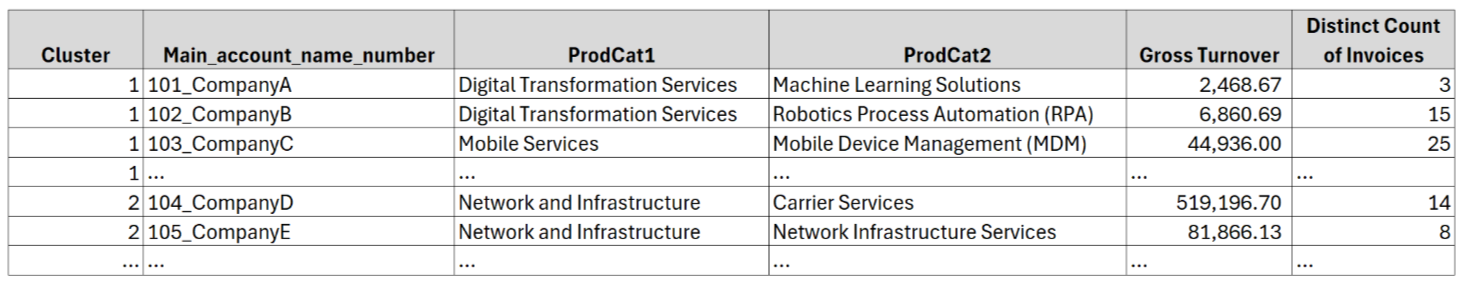






Here is a reference of how data for visualizations for **Product Categorization** looks like:

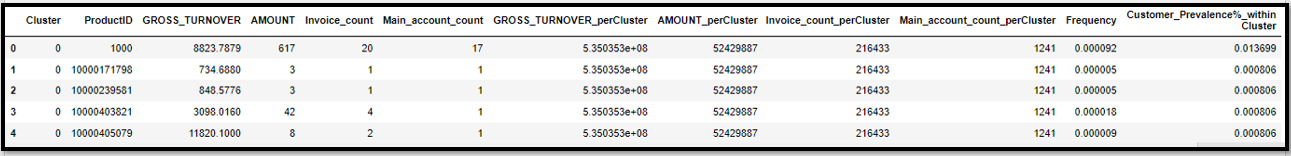

where:

- Product ID: SKU ID
- Gross Turnover (sum), Amount (sum), Invoice_count (distinct count of invoices), Main_account_count (distinct count of main accounts): fields aggregated at SKU level
- Above columns with _percluster: fields aggregated at cluster level
- Frequency (%) : number of transactions the SKU appeared on, when compared to all transactions in a cluster
- Customer Prevalence (%) within cluster : Percentage of customers within a cluster who purchase the SKU



In [144]:
print(f"Before preparing dataset: {df_segment_with_clusters.shape}")
tableau_customer = (
    df_segment_with_clusters.groupby( ['Cluster', 'Primary_Key', 'ProdCat1', 'ProdCat2'])
    .agg(
        Gross_Turnover=('GROSS_TURNOVER', 'sum'),
        Distinct_Invoices=('INVOICE_NUMBER', 'nunique')
    )
    .reset_index()
)

print("\nAfter preparing Tableau dataset:")
print(tableau_customer.shape)

display(tableau_customer.head())

Before preparing dataset: (644957, 22)

After preparing Tableau dataset:
(51379, 6)


,Cluster,Primary_Key,ProdCat1,ProdCat2,Gross_Turnover,Distinct_Invoices
0,0,100015_Customer Group_2149,Broadband and Internet Services,Broadband Internet (Fiber),9250.04,7
1,0,100015_Customer Group_2149,Cloud and Hosting Services,Public Cloud Services,124.69,2
2,0,100015_Customer Group_2149,Devices and Accessories,Data Center Equipment - Servers,132.17,1
3,0,100015_Customer Group_2149,Digital Transformation Services,Machine Learning Solutions,936.90,1
4,0,100015_Customer Group_2149,Digital Transformation Services,Robotics Process Automation (RPA),3169.43,2


In [145]:
# Step 1: Ensure 'Main_account_name_number' Exists
df_segment_with_clusters['Main_account_name_number'] = (
    df_segment_with_clusters['Main_account'] + ' - ' + df_segment_with_clusters['Main_account_name']
)

# Step 2: Prepare Product Categorization Dataset
tableau_product = df_segment_with_clusters.groupby(
    ['Cluster', 'ProductID']
).agg({
    'GROSS_TURNOVER': 'sum',
    'AMOUNT': 'sum',
    'INVOICE_NUMBER': 'nunique',
    'Main_account_name_number': 'nunique'
}).reset_index()

# Step 3: Add Per Cluster Aggregations
cluster_aggregations = tableau_product.groupby('Cluster').agg({
    'GROSS_TURNOVER': 'sum',
    'AMOUNT': 'sum',
    'INVOICE_NUMBER': 'sum',
    'Main_account_name_number': 'sum'
}).add_suffix('_percluster').reset_index()

tableau_product = pd.merge(
    tableau_product,
    cluster_aggregations,
    on='Cluster',
    how='left'
)

# Step 4: Calculate Frequency (%) and Customer Prevalence (%)
tableau_product['Frequency'] = (
    tableau_product['INVOICE_NUMBER'] / tableau_product['INVOICE_NUMBER_percluster'] * 100
)
tableau_product['Customer Prevalence (%) within Cluster'] = (
    tableau_product['Main_account_name_number'] / tableau_product['Main_account_name_number_percluster'] * 100
)

# Step 5: Verify the Dataset
print("Shape before:", df_segment_with_clusters.shape)
print("Shape after:", tableau_product.shape)
display(tableau_product.head())


Shape before: (644957, 23)
Shape after: (104806, 12)


,Cluster,ProductID,GROSS_TURNOVER,AMOUNT,INVOICE_NUMBER,Main_account_name_number,GROSS_TURNOVER_percluster,AMOUNT_percluster,INVOICE_NUMBER_percluster,Main_account_name_number_percluster,Frequency,Customer Prevalence (%) within Cluster
0,0,1,71.70,4,2,2,557368753.37,50206809,461232,294007,0.00,0.00
1,0,1000,8043.06,556,14,13,557368753.37,50206809,461232,294007,0.00,0.00
2,0,10000086294,15067.88,30,3,1,557368753.37,50206809,461232,294007,0.00,0.00
3,0,10000263597,696.12,6,1,1,557368753.37,50206809,461232,294007,0.00,0.00
4,0,10000435227,2188.59,81,1,1,557368753.37,50206809,461232,294007,0.00,0.00


In [146]:
# Export customer segmentation table
tableau_customer.to_csv('tableau_customer_segmentation.csv', index=False)

# Export product segmentation table
tableau_product.to_csv('tableau_product_segmentation.csv', index=False)

In [147]:
print("Shape of dataframe:", df_Cleaned.shape)
# Export cleaned after pareto
df_Cleaned.to_csv('dataset_after_pareto.csv', index=False)

Shape of dataframe: (644957, 20)


In [148]:
print(df_segment_with_clusters.columns.tolist())

['INDEX', 'INVOICE_NUMBER', 'DOCUMENT_DATE', 'CUSTOMER_NUMBER', 'Main_account', 'Main_account_name', 'PRODUCT', 'Position_type_order_line', 'GROSS_TURNOVER', 'AMOUNT', 'CUSTOMER_NAME', 'ACCOUNT_GROUP_TXT', 'CVR_Company_status', 'Main_account_ID', 'Customer_type', 'ProductID', 'ProductCategoryID', 'ProdCat2', 'ProdCat1', 'Invoice_flag', 'Primary_Key', 'Cluster', 'Main_account_name_number']


***The End***